<a href="https://colab.research.google.com/github/SolJosefinaMercado/ProcesamientoDelHabla/blob/main/MERCADO_SOLJOSEFINA_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Sol Josefina Mercado Jacobsen**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [68]:
# instalo dependencias necesarias para web scraping y visualización de datos
# request solicitud HTTP
# beautiful soup para parsear el codigo HTML y poder navegar por la estructura
# wordcloud y matplotlib para graficar la nube de palabras
!pip install requests beautifulsoup4 wordcloud matplotlib

## Extraccion (Funcion para scraping)

In [69]:
# @title
# importar librerias
import requests
from bs4 import BeautifulSoup

# creacion de la funcion para extraer el discurso de la pagina web

def extraer_discurso(url):
    # headers evita bloqueos de seguridad la web al hacer scraping nos identifica
    # como un navegador web
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"}

    response = requests.get(url, headers=headers)

    response.raise_for_status()  # Verifica si la solicitud fue exitosa

    sopa = BeautifulSoup(response.content, "html.parser")

    # los paramentros de busqueda se ajustan a la estructura de la pagina web,
    # primero se busca un div con la clase 'views-field-body', si no se encuentra
    # se busca un article, si tampoco se encuentra se buscan todos los parrafos <p>
    # esta decision la tome en base a la estructura de la pagina web que contiene el discurso

    contenedor = sopa.find('div', class_ = 'views-field-body') or sopa.find('article')

    if contenedor:
        parrafos = contenedor.find_all('p')
    else:
        parrafos = sopa.find_all('p')

    # unimos todo el texto obtenido en un solo string, separando los párrafos con dos saltos de línea

    texto_discurso = "\n\n".join([p.get_text(strip=True) for p in parrafos if p.get_text(strip=True)])
    return texto_discurso

Extraccion desde url utilizando la funcion <extraer_discurso>, muestro los primeros 500 caracteres

In [70]:
# @title
# declaro la url donde esta alojado el discurso que quiero extraer
url_discurso = "https://www.casarosada.gob.ar/informacion/discursos/51360-cadena-nacional-del-presidente-javier-milei-sobre-la-causa-malvinas"

# Extraccion mediante funcion creada previamente
discurso = extraer_discurso(url_discurso)

# muestro los primeros 500 caracteres para verificar que se haya extraído correctamente
print(discurso[:500])

Cadena Nacional del Presidente Javier Milei sobre la Causa Malvinas

Argentinos, buenas noches. Hoy estoy aquí para informarles acerca de una serie de decisiones que hemos tomado respecto al ejercicio de nuestra soberanía sobre las Islas Malvinas, producto de meses de trabajo conjunto entre distintas áreas del Estado nacional.

En primer lugar, quiero ser claro con el mundo y expresar la posición del Estado argentino. Las Malvinas son argentinas, por historia y por derecho. No hay discusión al r


In [71]:
# @title
print(f"Longitud total del discurso: {len(discurso)} caracteres")

Longitud total del discurso: 12825 caracteres


Guardado del texto extraido como: "discurso_malvinas_TP1.txt"

In [72]:
# @title
nombre_archivo = "discurso_malvinas_TP1.txt"

with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(discurso)

print(f"Discurso guardado exitosamente en '{nombre_archivo}' listo para el análisis.")

Discurso guardado exitosamente en 'discurso_malvinas_TP1.txt' listo para el análisis.


## 2- Preprocesamiento

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

`notas:`

Para que una nube de palabras sea útil, es fundamental remover términos comunes que no aportan significado analítico (como "el", "la", "de", "que", "y"). Definiremos una lista personalizada de palabras vacías en español.

Antes de aplicar re.findall, el texto está almacenado en la variable texto_minuscula como una única cadena de texto continua (un string largo o bloque de texto completo) que contiene todas las oraciones juntas, con sus espacios, saltos de línea, puntos, comas y otros símbolos mezclados, tal como fue leído del archivo original.

Lo que hace la expresión regular es actuar como un filtro de búsqueda sobre ese bloque masivo: lo recorre de principio a fin y, cada vez que detecta un fragmento que cumple exactamente con las reglas del patrón (\b[a-záéíóúñü]+\b), lo "recorta" y lo almacena como un elemento independiente dentro de una lista de Python palabras

In [ ]:
# @title
import re

# convierto a minusculas
texto_minuscula = discurso.lower()

# re.findall(patrón, texto)
# elimino puntuación y limpio usando regex
palabras = re.findall(r'\b[a-záéíóúñü]+\b', texto_minuscula)

# Mostrar las primeras 20 palabras para verificar
print(palabras[:20])
print('-' * 60)
print(f'Cantidad de palabras sin filtrado de Stopwords: {len(palabras)}')  # Mostrar el número total de palabras encontradas

['cadena', 'nacional', 'del', 'presidente', 'javier', 'milei', 'sobre', 'la', 'causa', 'malvinas', 'argentinos', 'buenas', 'noches', 'hoy', 'estoy', 'aquí', 'para', 'informarles', 'acerca', 'de']
------------------------------------------------------------
Cantidad de palabras sin filtrado de Stopwords: 1975


In [73]:
# @title
stopwords_espaniol = {
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "para",
    "con", "no", "una", "su", "lo", "como", "más", "pero", "sus", "le", "ya", "o", "este",
    "sí", "porque", "esta", "entre", "cuando", "muy", "sin", "sobre", "también", "me",
    "hasta", "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos", "uno",
    "les", "ni", "contra", "otros", "ese", "eso", "ante", "ellos", "e", "esto", "mí",
    "antes", "algunos", "qué", "unos", "yo", "otro", "otras", "otra", "él", "tanto",
    "esa", "estos", "mucho", "quienes", "nada", "muchos", "cual", "sea", "poco", "ella",
    "estar", "haber", "otras", "aunque", "ellas", "estuve", "estuviste", "estuvo",
    "ser", "son", "fue", "ha", "han", "hay", "hacer", "hizo", "estado", "está", "están",
    "será", "sido", "tiene", "tienen", "tener", "su", "sus", "les", "nos", "nosotros"
}
# filtrar stopwords del español y aquellas con menos de 3 caracteres
palabras_filtradas = [p for p in palabras if p not in stopwords_espaniol and len(p) > 2]

# Mostrar las primeras 20 palabras filtradas para verificar
print(palabras_filtradas[:20])
print('-' * 60)
print(f"Palabras listas para la nube tras el filtrado de Stopwords: {len(palabras_filtradas)}")

['cadena', 'nacional', 'presidente', 'javier', 'milei', 'causa', 'malvinas', 'argentinos', 'buenas', 'noches']
------------------------------------------------------------
Palabras listas para la nube tras el filtrado de Stopwords: 10


In [74]:
# unir las palaras filtradas en un solo string para generar la nube de palabras
texto_filtrado = " ".join(palabras_filtradas)

print(texto_filtrado[:100])


cadena nacional presidente javier milei causa malvinas argentinos buenas noches


Guardado intermedio en txt

In [75]:
# @title
nombre_archivo = "discurso_malvinas_TP1_Filtrado.txt"

with open(nombre_archivo, "w", encoding="utf-8") as f:
    f.write(texto_filtrado)

print(f"Discurso guardado exitosamente en '{nombre_archivo}' listo para el análisis.")

Discurso guardado exitosamente en 'discurso_malvinas_TP1_Filtrado.txt' listo para el análisis.


# Generacion y visualizacion de la nube de palabras
Usando WordCloud y matplotlib

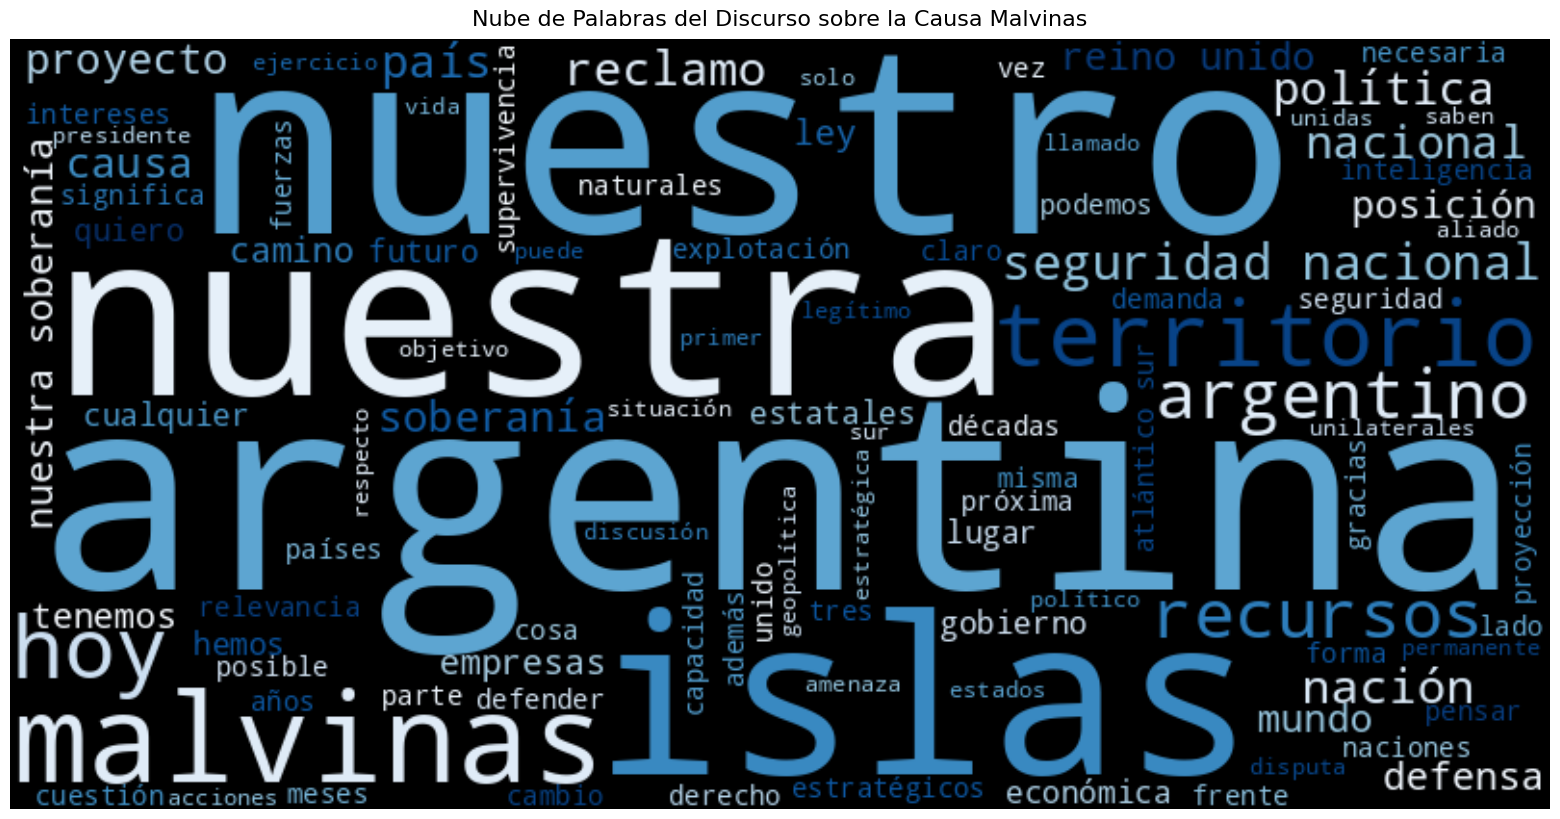

In [ ]:
# @title
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# parametros de la nube de palabras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Blues_r',
    max_words=100,
    contour_width=3,
    contour_color='steelblue',
).generate(texto_filtrado)

# mostrar en el notebook la nube de palabras
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # ocultar los ejes
plt.title("Nube de Palabras del Discurso sobre la Causa Malvinas", fontsize=16, pad= 10)
plt.show()

# 2.3 Usando el texto que conseguiste en el punto 1.



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


`notas: `

El orden lógico y profesional de un pipeline de texto es el siguiente:

Limpieza de ruido (URLs, HTML, saltos de línea).

Segmentación en oraciones.

Tokenización en palabras.

Lematización o Stemming (agrupar variantes de una misma palabra).

Eliminación de stopwords.

Vectorización (TF-IDF o CountVectorizer).

In [ ]:
# importacion de las librerias necesarias
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize # tokenizador de sentence y words
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

# para descomponer en oraciones debo usar el texto crudo, ya que el texto filtrado no tiene puntuación y no se puede separar en oraciones
texto_crudo = discurso.lower()

# reemplazo los saltos de línea por espacios para que el texto sea continuo
# y posteriormente pueda ser tokenizado en oraciones y palabras (caso 'malvinas/n/nargentinos')
texto_sin_saltos = texto_crudo.replace('\n', ' ').replace('\r', ' ')

# verifico con las primeras 100 caracteres
print(texto_sin_saltos[:100])

cadena nacional del presidente javier milei sobre la causa malvinas  argentinos, buenas noches. hoy 


## Descomposicion de oraciones

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [77]:
oraciones = sent_tokenize(texto_sin_saltos, language='spanish') # sentence tokenize
print(f'oraciones encontradas: {len(oraciones)}')
print('-' * 60)
print(oraciones[:2])

oraciones encontradas: 94
------------------------------------------------------------
['cadena nacional del presidente javier milei sobre la causa malvinas  argentinos, buenas noches.', 'hoy estoy aquí para informarles acerca de una serie de decisiones que hemos tomado respecto al ejercicio de nuestra soberanía sobre las islas malvinas, producto de meses de trabajo conjunto entre distintas áreas del estado nacional.']


## Tokenizacion en palabras

TF-IDF da un puntaje alto a palabras que son frecuentes en un documento específico pero poco comunes en el resto del corpus

* TF se calcula por separado en cada documento (oracion)
* IDF se calcula mirando todo el corpus

## Lematizacion:
Por que? porque respeta el diccionario y la gramatica (utiliza diccionario y reglas morfologicas del español para devolver el lema o palabra base) y este es un texto cargado de conceptos

* Sin lemantizar la matriz final queda con terminos similares como ultimo / ultimos que en esencia son la misma palabra en singular y plural, lo que no añade nada al analisis

In [ ]:
# @title
# Instalar la librería spaCy
!pip install spacy

# Descargar el modelo de idioma español
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 89.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [78]:
import spacy

# Cargar el modelo de spaCy en español
nlp = spacy.load("es_core_news_sm")

lista_de_oraciones = oraciones

oraciones_lematizadas = []

for oracion in lista_de_oraciones:
    doc = nlp(oracion)
    # # Filtramos: que no sea stopword, que no sea puntuación, que no sea espacio en blanco
    # y que tenga más de 2 caracteres
    tokens_lema = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space and len(token.text) > 2
    ]
    oraciones_lematizadas.append(" ".join(tokens_lema))

print(oraciones_lematizadas[:5])  # Mostrar las primeras 5 oraciones lematizadas para verificar

['cadena nacional presidente javier milei causa malvina argentino noche', 'informar él acerca serie decisión tomar ejercicio soberanía isla malvina producto mes trabajo conjunto distinto área nacional', 'lugar querer mundo expresar posición argentino', 'malvina argentino historia derecho', 'discusión']


In [79]:
# utilizo la lista de stopwords de la libreria nltk
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True


#### 2.3.2 Determina la longitud de tu vocabulario.


#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [80]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

tfidf_vectorizer = TfidfVectorizer()

# Aplico fit_transform sobre la lista de oraciones ya lematizadas y sin stopwords (cada oración es un documento)
# obtengo la matriz dispersa
matriz_tfidf = tfidf_vectorizer.fit_transform(oraciones_lematizadas)

# Longitud del vocabulario resultante
# se cuentan solo las palabras unicas, sin repeticiones
print('-' * 60)
print(f"Longitud del vocabulario: {len(tfidf_vectorizer.get_feature_names_out())}")
print('-' * 60)
vocabulario = tfidf_vectorizer.get_feature_names_out()
print(vocabulario[:20])


------------------------------------------------------------
Longitud del vocabulario: 510
------------------------------------------------------------
['180' '1833' '26659' 'abandonar' 'accionista' 'acción' 'acechar'
 'acelerar' 'acerca' 'acompañir' 'acostumbrar' 'actividad' 'actor'
 'actuar' 'adicional' 'adopción' 'aeroespacial' 'afectado' 'afectar'
 'afín']


In [81]:
# visualizo la matriz dispersa
# 94 filas = 94 oraciones / documentos
# 510 columnas = 510 palabras unicas
print(matriz_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 865 stored elements and shape (94, 510)>
  Coords	Values
  (0, 58)	0.3999990547652729
  (0, 315)	0.22388878050145405
  (0, 379)	0.36663252964967585
  (0, 276)	0.3999990547652729
  (0, 303)	0.3999990547652729
  (0, 68)	0.29690671410191866
  (0, 292)	0.24596475416065666
  (0, 34)	0.2288777004504476
  (0, 325)	0.36663252964967585
  (1, 315)	0.15429136122346843
  (1, 292)	0.16950486150956107
  (1, 250)	0.2756565045805582
  (1, 509)	0.19703846148343698
  (1, 8)	0.2756565045805582
  (1, 451)	0.2756565045805582
  (1, 113)	0.2756565045805582
  (1, 475)	0.25266220103461035
  (1, 158)	0.25266220103461035
  (1, 457)	0.16530212945493813
  (1, 274)	0.16138947951847474
  (1, 390)	0.2756565045805582
  (1, 300)	0.23634748303199762
  (1, 476)	0.2756565045805582
  (1, 89)	0.2756565045805582
  (1, 150)	0.25266220103461035
  :	:
  (87, 99)	0.28223900053179435
  (87, 118)	0.28223900053179435
  (87, 65)	0.32918064260651225
  (87, 359)	0.329180642

In [82]:
# @title
import pandas as pd

# Convierto la matriz dispersa (sparse matrix) a un array de numpy y armamos el DataFrame
df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

# Para ver mejor las filas, el índice son las oraciones originales
df_tfidf.index = [f"Oración {i+1}" for i in range(len(oraciones_lematizadas))]

# DataFrame
df_tfidf.head(10)

,180,1833,26659,abandonar,accionista,acción,acechar,acelerar,acerca,acompañir,...,violación,violencia,violentir,vivir,volver,voz,vulnerar,yacer,área,él
Oración 1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.275657,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.275657,0.197038
Oración 3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 5,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 6,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 7,0.0,0.322622,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 8,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 9,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
Oración 10,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000


## Cuales son las palabras mas importantes de todo el texto ?

In [83]:
# Sumamos los valores de TF-IDF por columna y los ordenamos de mayor a menor
palabras_importantes = df_tfidf.sum().sort_values(ascending=False)

print("Top 10 palabras más importantes del texto:")
print(palabras_importantes.head(10))

Top 10 palabras más importantes del texto:
argentina    3.704304
malvina      3.495823
argentino    3.299580
nacional     3.251492
camino       3.010223
isla         2.997992
reclamo      2.773779
seguridad    2.719284
soberanía    2.663636
nación       2.562152
dtype: float64


## De que habla cada oracion en particular ?

In [84]:
# Para cada oración, encontramos la columna con el valor máximo
for idx, row in df_tfidf.iterrows():
    palabra_clave = row.idxmax()
    peso = row.max()
    if peso > 0:  # Si la oración tiene palabras con peso
        print(f"[{idx}] Palabra más representativa: '{palabra_clave}' (Peso: {peso:.3f})")

[Oración 1] Palabra más representativa: 'cadena' (Peso: 0.400)
[Oración 2] Palabra más representativa: 'acerca' (Peso: 0.276)
[Oración 3] Palabra más representativa: 'expresar' (Peso: 0.513)
[Oración 4] Palabra más representativa: 'historia' (Peso: 0.640)
[Oración 5] Palabra más representativa: 'discusión' (Peso: 1.000)
[Oración 6] Palabra más representativa: 'formar' (Peso: 0.535)
[Oración 7] Palabra más representativa: '1833' (Peso: 0.323)
[Oración 8] Palabra más representativa: 'argumento' (Peso: 0.286)
[Oración 9] Palabra más representativa: 'sostener' (Peso: 0.581)
[Oración 10] Palabra más representativa: 'sur' (Peso: 0.402)
[Oración 11] Palabra más representativa: 'territorio' (Peso: 0.301)
[Oración 12] Palabra más representativa: 'bilateral' (Peso: 0.284)
[Oración 13] Palabra más representativa: 'causa' (Peso: 0.596)
[Oración 14] Palabra más representativa: 'geopolítico' (Peso: 0.409)
[Oración 15] Palabra más representativa: 'apoyo' (Peso: 0.270)
[Oración 16] Palabra más represe

Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

En resumen, seguí un pipeline clásico de NLP: limpieza, segmentación en oraciones, tokenización, lematización, eliminación de stopwords y vectorización con TF-IDF. Lo interesante de este trabajo fue ver cómo cada paso depende del anterior —por ejemplo, necesitar el texto crudo con puntuación para segmentar en oraciones, aunque ya lo hubiera filtrado antes para la nube de palabras. Con esto termino la presentación de mi TP1, gracias!!